<a href="https://colab.research.google.com/github/Froststar16/canopy-watch-hyderabad/blob/main/notebooks/05_tree_cover_dynamicworld.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Canopy Watch — Hyderabad
### Phase 4 (continued): Satellite-native tree cover via Dynamic World

FMIS's Haritha Haram tracking data wasn't usable (portal returned all zeros as of July 2026), so
this notebook takes the more self-contained route: use a purpose-built tree-cover CV model
directly on the satellite record, instead of relying on official planting claims.

**Dynamic World** (`GOOGLE/DYNAMICWORLD/V1`) is a near-real-time land cover model — a deep neural
net run on every cloud-free Sentinel-2 scene since June 2015 — that outputs a per-pixel
probability for 9 classes, including a dedicated `trees` band. At 10m resolution, it's a more
literal "tree canopy" signal than NDVI, which can't distinguish trees from grass, crops, or other
greenery.

Section 1 below reuses your actual Phase 2 boundary-loading code (downloader, robust KML
fallback parser, geometry repair, `gdf_to_ee_safe`) unchanged, so this notebook works from a
fresh Colab runtime without depending on any earlier notebook still being open.

This notebook:
1. Reloads the GHMC ward boundaries exactly as Phase 2 did
2. Computes a yearly mean `trees`-probability composite per ward, 2016–present, via the same
   `reduceRegions` pattern you used for NDVI
3. Sanity-checks the new metric against your existing citywide NDVI trend
4. Computes ward-level tree-cover change (first year vs. most recent) and cross-references it
   against the Phase 3 heat-risk ward shortlist
5. Documents the limitations of using a global CV model's probability output as a tree-cover proxy

## 1. Setup

In [1]:
!pip install geopandas geemap --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 22.4 MB/s eta 0:00:00


In [2]:
import ee
import geemap
import geopandas as gpd
import pandas as pd
import requests
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from shapely.geometry import Polygon, MultiPolygon, mapping
from shapely.validation import make_valid
from shapely.geometry.polygon import orient

ee.Authenticate()
ee.Initialize(project='canopy-watch-hyderabad')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
OUTPUT_DIR = '/content/drive/MyDrive/canopy-watch-hyderabad/outputs'
DATA_DIR = '/content/drive/MyDrive/canopy-watch-hyderabad/data'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

Mounted at /content/drive


## 2. Load ward boundaries — reusing your Phase 2 code unchanged

Same downloader + robust KML loader (native geopandas/GDAL first, manual XML parser fallback)
+ geometry repair + `gdf_to_ee_safe` from `02_ward_level_ndvi.ipynb`. If `ghmc_wards.kml` is
already sitting in `data/` from Phase 2's run, this reads the cached copy instead of
re-downloading.

In [4]:
WARDS_KML_URL = "https://data.opencity.in/dataset/15cb7d8d-eed1-4aad-8cd7-f281cbf4f94f/resource/14b033e3-3721-4149-8326-cc29420e062e/download/ghmc_wards.kml"

wards_kml_path = f'{DATA_DIR}/ghmc_wards.kml'
if not os.path.exists(wards_kml_path):
    print("No cached ward file found -- downloading from OpenCity India...")
    r = requests.get(WARDS_KML_URL, timeout=60)
    r.raise_for_status()
    with open(wards_kml_path, 'wb') as f:
        f.write(r.content)
    print("Downloaded.")
else:
    print(f"Using cached file: {wards_kml_path}")

Using cached file: /content/drive/MyDrive/canopy-watch-hyderabad/data/ghmc_wards.kml


In [5]:
NS = {"kml": "http://www.opengis.net/kml/2.2"}

def load_kml_as_gdf(path):
    """Robust KML loader: try geopandas/GDAL first, fall back to manual XML parsing."""
    for kwargs in ({}, {"driver": "KML"}, {"driver": "LIBKML"}):
        try:
            gdf = gpd.read_file(path, **kwargs)
            if len(gdf) > 0:
                print(f"Loaded '{path}' via geopandas ({kwargs or 'default driver'}): {len(gdf)} feature(s)")
                return gdf
        except Exception:
            pass

    print(f"GDAL KML driver unavailable -- falling back to manual parser for '{path}'")
    tree = ET.parse(path)
    root = tree.getroot()
    records, geoms = [], []
    for placemark in root.iter("{http://www.opengis.net/kml/2.2}Placemark"):
        props = {}
        for sd in placemark.iter("{http://www.opengis.net/kml/2.2}SimpleData"):
            props[sd.get("name")] = sd.text
        polygons = []
        for poly_el in placemark.iter("{http://www.opengis.net/kml/2.2}Polygon"):
            outer = poly_el.find(".//kml:outerBoundaryIs/kml:LinearRing/kml:coordinates", NS)
            if outer is None or not outer.text:
                continue
            ring = []
            for triple in outer.text.strip().split():
                lon, lat = map(float, triple.split(",")[:2])
                ring.append((lon, lat))
            if len(ring) >= 4:
                polygons.append(Polygon(ring))
        if not polygons:
            continue
        geom = polygons[0] if len(polygons) == 1 else MultiPolygon(polygons)
        geoms.append(geom)
        records.append(props if props else {"id": placemark.get("id")})
    gdf = gpd.GeoDataFrame(records, geometry=geoms, crs="EPSG:4326")
    print(f"Loaded '{path}' via manual parser: {len(gdf)} feature(s)")
    return gdf

wards_gdf = load_kml_as_gdf(wards_kml_path)
wards_gdf = wards_gdf.set_crs("EPSG:4326", allow_override=True)
print(f"Wards: {len(wards_gdf)}")

Loaded '/content/drive/MyDrive/canopy-watch-hyderabad/data/ghmc_wards.kml' via geopandas (default driver): 155 feature(s)
Wards: 155


In [6]:
split_ward = wards_gdf['ward'].str.split('-', n=1, expand=True)
wards_gdf['ward_no'] = split_ward[0].str.strip()
wards_gdf['ward_name'] = split_ward[1].str.strip()

wards_gdf = wards_gdf[['ward_no', 'ward_name', 'CIRCLE', 'ZONE', 'geometry']].copy()
wards_gdf.columns = ['ward_no', 'ward_name', 'circle', 'zone', 'geometry']
wards_gdf.head()

,ward_no,ward_name,circle,zone,geometry
0,127,RANGAREDDY NAGAR,25-QUTUBULLAPUR,KUKATPALLY ZONE,"MULTIPOLYGON (((78.45031 17.48797, 78.45029 17..."
1,119,OLD BOWENPALLY,24-KUKATPALLY,KUKATPALLY ZONE,"MULTIPOLYGON (((78.47869 17.48565, 78.47943 17..."
2,145,SEETHAPHALMANDI,29-SECUNDERABAD,SECUNDERABAD ZONE,"MULTIPOLYGON (((78.52062 17.4268, 78.52074 17...."
3,146,BOUDHA NAGAR,29-SECUNDERABAD,SECUNDERABAD ZONE,"MULTIPOLYGON (((78.52018 17.4193, 78.51998 17...."
4,147,BANSILALPET,30-BEGUMPET,SECUNDERABAD ZONE,"MULTIPOLYGON (((78.50605 17.43299, 78.50621 17..."


In [7]:
def _polygons_only(geom):
    """Flatten a Polygon/MultiPolygon/GeometryCollection down to a list of Polygons."""
    if geom.geom_type == 'Polygon':
        return [geom]
    elif geom.geom_type == 'MultiPolygon':
        return list(geom.geoms)
    elif geom.geom_type == 'GeometryCollection':
        out = []
        for g in geom.geoms:
            out.extend(_polygons_only(g))
        return out
    return []

def clean_geometry(geom):
    """Repair invalid geometry and enforce GeoJSON-compliant ring winding (CCW exterior)."""
    if geom is None or geom.is_empty:
        return None
    if not geom.is_valid:
        geom = make_valid(geom)
    polys = [p for p in _polygons_only(geom) if p.area > 0]
    if not polys:
        return None
    polys = [orient(p, sign=1.0) for p in polys]
    return polys[0] if len(polys) == 1 else MultiPolygon(polys)

def report_and_clean(gdf, name):
    n_before_invalid = (~gdf.geometry.is_valid).sum()
    gdf = gdf.copy()
    gdf['geometry'] = gdf.geometry.apply(clean_geometry)
    n_dropped = gdf['geometry'].isna().sum()
    gdf = gdf[gdf['geometry'].notna()].reset_index(drop=True)
    print(f"{name}: {n_before_invalid} invalid geometrie(s) repaired, {n_dropped} unrepairable feature(s) dropped, {len(gdf)} remain.")
    return gdf

wards_gdf = report_and_clean(wards_gdf, 'wards_gdf')

wards_gdf: 0 invalid geometrie(s) repaired, 0 unrepairable feature(s) dropped, 155 remain.


In [8]:
def gdf_to_ee_safe(gdf):
    """Convert feature-by-feature so one bad geometry doesn't sink the whole collection."""
    features, failed = [], []
    prop_cols = [c for c in gdf.columns if c != 'geometry']
    for idx, row in gdf.iterrows():
        try:
            ee_geom = ee.Geometry(mapping(row.geometry))
            props = {c: row[c] for c in prop_cols if row[c] == row[c]}  # drop NaNs
            features.append(ee.Feature(ee_geom, props))
        except Exception as e:
            failed.append((idx, row.get('ward_no', idx), str(e)))
    if failed:
        print(f"WARNING: {len(failed)} feature(s) still failed to convert and were skipped:")
        for idx, ident, err in failed:
            print(f"  row {idx} (ward_no={ident}): {err}")
    else:
        print(f"All {len(features)} features converted successfully.")
    return ee.FeatureCollection(features)

wards_ee = gdf_to_ee_safe(wards_gdf)
ghmc_geometry = wards_ee.geometry()
print("Wards in Earth Engine:", wards_ee.size().getInfo())

All 155 features converted successfully.
Wards in Earth Engine: 155


## 3. Dynamic World: yearly ward-level tree probability

Same shape as your Phase 2 `reduceRegions` call, same `scale=10` and `tileScale=4` for
consistency (and because the ward polygons plus 10m pixels need it to avoid aggregation limits).

**On the output property name:** your Phase 2 NDVI code reads `props.get('mean')` from
`reduceRegions` output, not the band name — that's the actual Earth Engine convention for a
single-band image reduced with `ee.Reducer.mean()`. This should hold for the single-band `trees`
composite below too, but the check cell confirms it before the full loop runs, just in case.

In [9]:
def yearly_trees_image(year, region):
    start = f'{year}-01-01'
    end = f'{year}-12-31'
    return (
        ee.ImageCollection('GOOGLE/DYNAMICWORLD/V1')
        .filterDate(start, end)
        .filterBounds(region)
        .select('trees')
        .mean()
    )

YEARS = list(range(2016, 2027))  # matches Phase 2/3's year range

In [10]:
# Quick check on one year + a few wards before committing to the full 10-year loop
test_trees = yearly_trees_image(2020, ghmc_geometry)
test_stats = test_trees.reduceRegions(
    collection=wards_ee.limit(3),
    reducer=ee.Reducer.mean(),
    scale=10,
    tileScale=4
).getInfo()

for f in test_stats['features']:
    print(f['properties'])

{'circle': '25-QUTUBULLAPUR', 'mean': 0.08292496034530322, 'ward_name': 'RANGAREDDY NAGAR', 'ward_no': '127', 'zone': 'KUKATPALLY ZONE'}
{'circle': '24-KUKATPALLY', 'mean': 0.046665460792454504, 'ward_name': 'OLD BOWENPALLY', 'ward_no': '119', 'zone': 'KUKATPALLY ZONE'}
{'circle': '29-SECUNDERABAD', 'mean': 0.03091941761330224, 'ward_name': 'SEETHAPHALMANDI', 'ward_no': '145', 'zone': 'SECUNDERABAD ZONE'}


Confirm the property holding the mean tree probability in the printed output above (expected:
`'mean'`, matching your NDVI convention). Adjust `TREE_PROB_COL` below if it's different.

In [11]:
TREE_PROB_COL = 'mean'  # matches the Phase 2 NDVI reduceRegions convention

In [12]:
ward_rows = []
for year in YEARS:
    trees_img = yearly_trees_image(year, ghmc_geometry)
    stats = trees_img.reduceRegions(
        collection=wards_ee,
        reducer=ee.Reducer.mean(),
        scale=10,
        tileScale=4
    )
    features = stats.getInfo()['features']
    for f in features:
        props = f['properties']
        ward_rows.append({
            'year': year,
            'ward_no': props.get('ward_no'),
            'ward_name': props.get('ward_name'),
            'mean_tree_prob': props.get(TREE_PROB_COL)
        })
    print(f'{year}: {len(features)} wards processed')

dw_ward_df = pd.DataFrame(ward_rows)
dw_ward_df.to_csv(f'{OUTPUT_DIR}/hyderabad_treecover_dynamicworld_by_ward.csv', index=False)
dw_ward_df.head()

2016: 155 wards processed
2017: 155 wards processed
2018: 155 wards processed
2019: 155 wards processed
2020: 155 wards processed
2021: 155 wards processed
2022: 155 wards processed
2023: 155 wards processed
2024: 155 wards processed
2025: 155 wards processed
2026: 155 wards processed


,year,ward_no,ward_name,mean_tree_prob
0,2016,127,RANGAREDDY NAGAR,0.060606
1,2016,119,OLD BOWENPALLY,0.039321
2,2016,145,SEETHAPHALMANDI,0.029481
3,2016,146,BOUDHA NAGAR,0.030256
4,2016,147,BANSILALPET,0.033654


## 4. Sanity check against the existing NDVI trend

These two metrics measure related but different things (tree-specific probability vs. general
greenness), so expect them to track loosely, not match exactly.

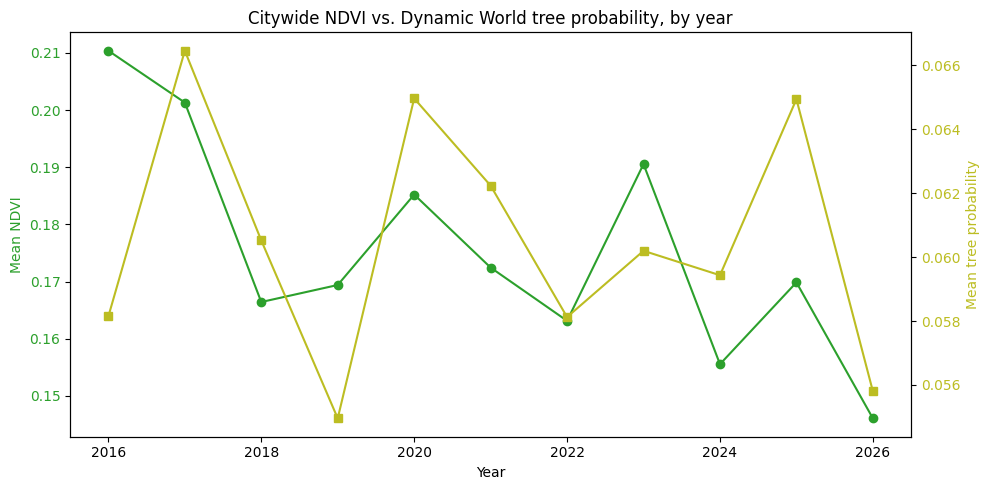

In [13]:
ndvi_df = pd.read_csv(f'{OUTPUT_DIR}/hyderabad_ndvi_yearly_realboundary.csv')

dw_city_df = dw_ward_df.groupby('year')['mean_tree_prob'].mean().reset_index()
compare_df = ndvi_df.merge(dw_city_df, on='year', how='inner')

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(compare_df['year'], compare_df['mean_ndvi'], color='tab:green', marker='o', label='Mean NDVI')
ax1.set_xlabel('Year')
ax1.set_ylabel('Mean NDVI', color='tab:green')
ax1.tick_params(axis='y', labelcolor='tab:green')

ax2 = ax1.twinx()
ax2.plot(compare_df['year'], compare_df['mean_tree_prob'], color='tab:olive', marker='s',
          label='Mean tree probability (Dynamic World)')
ax2.set_ylabel('Mean tree probability', color='tab:olive')
ax2.tick_params(axis='y', labelcolor='tab:olive')

plt.title('Citywide NDVI vs. Dynamic World tree probability, by year')
fig.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/ndvi_vs_treecover_sanity_check.png', dpi=150)
plt.show()

## 5. Ward-level tree-cover change: first year vs. most recent

Same approach as your Phase 3 heat-risk calculation — compare each ward's earliest and latest
complete year (excluding the current partial year).

In [14]:
complete_years = sorted(dw_ward_df['year'].unique())[:-1]  # drop current partial year
first_year, last_year = complete_years[0], complete_years[-1]

first_df = dw_ward_df[dw_ward_df['year'] == first_year][['ward_no', 'mean_tree_prob']].rename(
    columns={'mean_tree_prob': 'tree_prob_first'})
last_df = dw_ward_df[dw_ward_df['year'] == last_year][['ward_no', 'mean_tree_prob']].rename(
    columns={'mean_tree_prob': 'tree_prob_last'})

change_df = first_df.merge(last_df, on='ward_no', how='inner')
change_df['tree_prob_change'] = change_df['tree_prob_last'] - change_df['tree_prob_first']
change_df = change_df.sort_values('tree_prob_change')

change_df.to_csv(f'{OUTPUT_DIR}/hyderabad_treecover_change_by_ward.csv', index=False)
print(f"Comparing {first_year} to {last_year}")
change_df.head(10)  # steepest measured tree-cover decline

Comparing 2016 to 2025


,ward_no,tree_prob_first,tree_prob_last,tree_prob_change
150,4,0.104259,0.068647,-0.035612
77,9,0.077023,0.060166,-0.016857
83,59,0.111630,0.097161,-0.014468
30,106,0.096457,0.082547,-0.013910
73,113,0.108934,0.096367,-0.012567
55,13,0.067160,0.054944,-0.012216
51,11,0.152145,0.140516,-0.011629
63,126,0.056403,0.046847,-0.009556
27,105,0.141133,0.131715,-0.009418
49,12,0.108660,0.100280,-0.008380


## 6. Cross-reference against Phase 3 heat-risk wards

Does this independent, tree-specific signal agree with the NDVI/LST-based heat-risk shortlist
from Phase 3? Agreement strengthens confidence in both; disagreement is worth investigating rather
than discarding.

In [16]:
heat_risk_df = pd.read_csv(f'{OUTPUT_DIR}/hyderabad_heat_risk_wards.csv')
print("Heat-risk table columns:", list(heat_risk_df.columns))

# Align ward_no dtypes before merging -- Phase 3's heat-risk table stored it as int64,
# while this notebook keeps ward_no as a string (from splitting "127-WARD NAME" in Section 2)
heat_risk_df['ward_no'] = heat_risk_df['ward_no'].astype(str).str.strip()
change_df['ward_no'] = change_df['ward_no'].astype(str).str.strip()

cross_df = heat_risk_df.merge(change_df, on='ward_no', how='left')
cross_df.to_csv(f'{OUTPUT_DIR}/hyderabad_heat_risk_treecover_cross_check.csv', index=False)

n_unmatched = cross_df['tree_prob_change'].isna().sum()
print(f"{n_unmatched} of {len(cross_df)} heat-risk wards had no matching tree-cover row")
cross_df.head(15)

Heat-risk table columns: ['ward_no', 'ward_name', 'zone', 'ndvi_change', 'lst_change_c', 'heat_risk_score']
0 of 150 heat-risk wards had no matching tree-cover row


,ward_no,ward_name,zone,ndvi_change,lst_change_c,heat_risk_score,tree_prob_first,tree_prob_last,tree_prob_change
0,115,BALAJI NAGAR,KUKATPALLY ZONE,-0.085399,1.517550,2.371544,0.156370,0.160347,0.003976
1,99,VENGALRAO NAGAR,SERILINGAMPALLY ZONE,-0.049887,1.404690,1.903565,0.050039,0.048995,-0.001044
2,116,ALLAPUR,KUKATPALLY ZONE,-0.065281,1.232712,1.885524,0.055391,0.066951,0.011560
3,68,TOLICHOWKI,KHAIRATHABAD ZONE,-0.087588,0.820015,1.695892,0.092599,0.110320,0.017721
4,112,RAMACHANDRAPURAM,SERILINGAMPALLY ZONE,-0.073568,0.869622,1.605298,0.057636,0.062467,0.004831
5,92,VENKATESHWARA COLONY,KHAIRATHABAD ZONE,-0.064817,0.920650,1.568824,0.138940,0.131491,-0.007448
6,96,YOUSUFGUDA,SERILINGAMPALLY ZONE,-0.034388,1.135891,1.479767,0.043686,0.068022,0.024336
7,120,BALA NAGAR,KUKATPALLY ZONE,-0.070617,0.750065,1.456232,0.218753,0.220552,0.001798
8,118,FATEH NAGAR,KUKATPALLY ZONE,-0.034119,1.034643,1.375831,0.039104,0.041777,0.002674
9,67,GOLCONDA,KHAIRATHABAD ZONE,-0.061138,0.727831,1.339207,0.080830,0.101635,0.020805


## Limitations

- **Dynamic World is a probabilistic model output, not ground truth.** Accuracy varies, especially
  in mixed urban/vegetation scenes typical of Indian cities — treat `mean_tree_prob` as a
  tree-cover *likelihood* signal, not an exact canopy percentage or tree count.
- **10m resolution** may under-resolve individual street trees or young, isolated plantings —
  avenue plantation, one of Haritha Haram's main strategies, produces exactly this kind of sparse,
  linear pattern that's hard for any 10-30m pixel product to capture cleanly.
- **This measures all tree cover change citywide**, from any cause (construction-driven loss,
  private landscaping, any afforestation effort) — it can't attribute a specific change to
  Haritha Haram or rule it out.
- **The current year's composite is partial** — don't compare it directly to a full prior year
  without accounting for that.

## Next steps
- **Phase 4c (optional):** add the Hansen Global Forest Change `lossyear` band
  (`UMD/hansen/global_forest_change_2025_v1_13`) for confirmed year-stamped loss events per ward —
  complements this probability-based trend with discrete change detection.
- **Phase 4b (stretch):** ward-level Haritha Haram data via FMIS's geo-tagged site export or an
  RTI request.
- **Phase 5:** Streamlit + Folium/leafmap dashboard tying NDVI, LST, and this tree-cover layer
  together by ward.